# Phase 4, Module 4: Advanced Regression Concepts
Welcome to Module 4! So far, we have drawn straight lines through data. But what happens when the data naturally curves? 

In this notebook, we will explore:
1. **Polynomial Regression:** Allowing our models to bend.
2. **The Goldilocks Problem:** Visualizing Underfitting vs. Overfitting.
3. **Regularization:** Using Ridge and Lasso to keep our AI from memorizing the data.

In [1]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Import ML models and tools
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

print("Libraries imported! We are ready to tackle complex data.")

Libraries imported! We are ready to tackle complex data.


## 1. Polynomial Regression
Let's generate some curved data. Imagine this represents the energy consumption of a smart grid in Peshawar throughout the day: it starts low, peaks in the afternoon, and drops at night. A straight line will fail here.

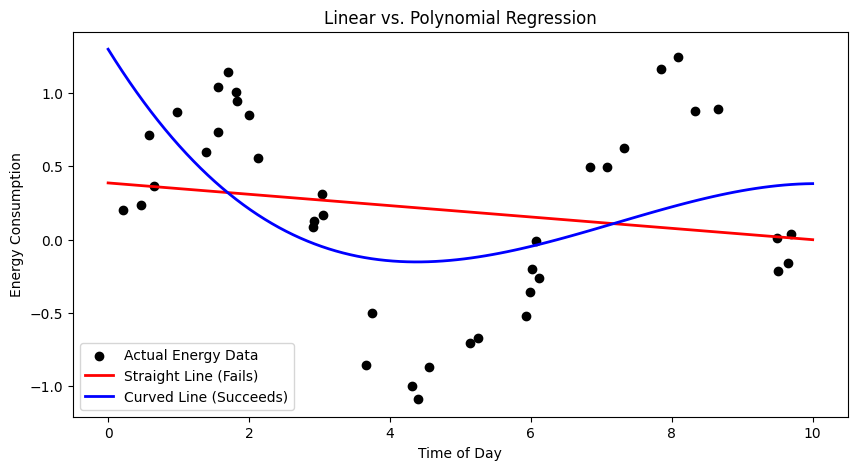

In [2]:
# Generate curved, non-linear data
np.random.seed(42)
X_time = np.sort(np.random.rand(40, 1) * 10, axis=0) # Time of day
y_energy = np.sin(X_time).ravel() + np.random.randn(40) * 0.2 # Energy usage with some noise

# 1. Train a standard Straight Line (Linear Regression)
straight_model = LinearRegression()
straight_model.fit(X_time, y_energy)

# 2. Train a Curved Line (Polynomial Regression - Degree 3)
# We use a pipeline to quickly turn our data into polynomial features, then apply regression
curved_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
curved_model.fit(X_time, y_energy)

# Generate points to draw smooth lines
X_plot = np.linspace(0, 10, 100)[:, np.newaxis]

# Visualize the difference
plt.figure(figsize=(10, 5))
plt.scatter(X_time, y_energy, color='black', label='Actual Energy Data')
plt.plot(X_plot, straight_model.predict(X_plot), color='red', label='Straight Line (Fails)', linewidth=2)
plt.plot(X_plot, curved_model.predict(X_plot), color='blue', label='Curved Line (Succeeds)', linewidth=2)

plt.title("Linear vs. Polynomial Regression")
plt.xlabel("Time of Day")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

## 2. Overfitting vs. Underfitting
If bending the line is good, is bending it 15 times better? **No.** 

* **Degree 1 (Underfitting):** Too simple. Misses the trend.
* **Degree 3 (Good Fit):** Captures the general shape.
* **Degree 15 (Overfitting):** Goes crazy trying to touch every single dot. It memorized the noise instead of learning the pattern.

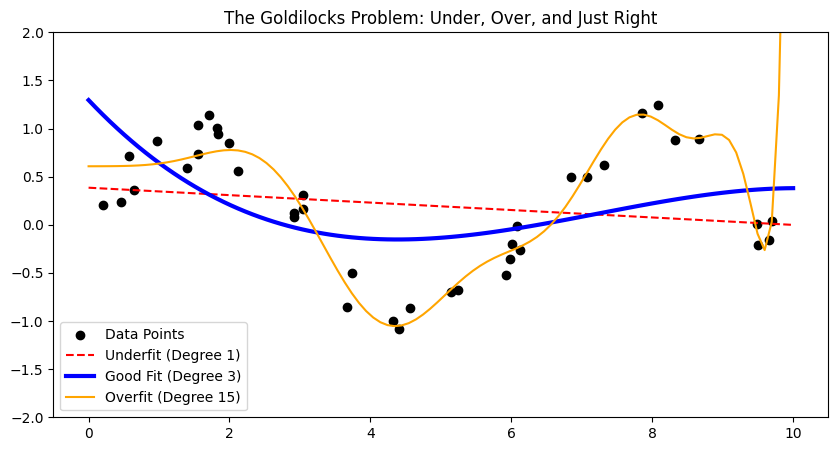

In [3]:
# Create a massively overfitted model (Degree 15)
overfit_model = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
overfit_model.fit(X_time, y_energy)

plt.figure(figsize=(10, 5))
plt.scatter(X_time, y_energy, color='black', label='Data Points')
plt.plot(X_plot, straight_model.predict(X_plot), color='red', linestyle='dashed', label='Underfit (Degree 1)')
plt.plot(X_plot, curved_model.predict(X_plot), color='blue', linewidth=3, label='Good Fit (Degree 3)')
plt.plot(X_plot, overfit_model.predict(X_plot), color='orange', label='Overfit (Degree 15)')

# Set y-limits to keep the crazy overfit line from ruining the graph's scale
plt.ylim(-2, 2)
plt.title("The Goldilocks Problem: Under, Over, and Just Right")
plt.legend()
plt.show()

## 3. Regularization (Taming the Overfit Model)
What if we have a highly complex model (like our Degree 15 curve), but we want to force it to behave? We use **Regularization**.

We will apply **Ridge Regression**. It looks at the crazy mathematically weights causing those huge spikes and physically shrinks them, smoothing the line back out into a generalized trend.

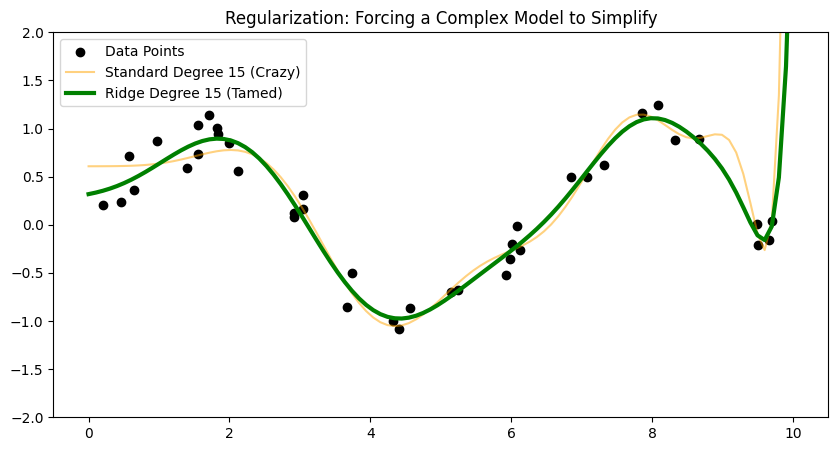

In [4]:
# Train a Degree 15 model, but this time use RIDGE to punish complexity
# alpha is the strictness of our punishment. Higher alpha = simpler model.
regularized_model = make_pipeline(PolynomialFeatures(degree=15), Ridge(alpha=1.0))
regularized_model.fit(X_time, y_energy)

plt.figure(figsize=(10, 5))
plt.scatter(X_time, y_energy, color='black', label='Data Points')
plt.plot(X_plot, overfit_model.predict(X_plot), color='orange', alpha=0.5, label='Standard Degree 15 (Crazy)')
plt.plot(X_plot, regularized_model.predict(X_plot), color='green', linewidth=3, label='Ridge Degree 15 (Tamed)')

plt.ylim(-2, 2)
plt.title("Regularization: Forcing a Complex Model to Simplify")
plt.legend()
plt.show()

---
## 🎓 Student Task: The Infection Curve

You are working with health data tracking a localized viral outbreak. The data shows the number of days since the outbreak began, and the total number of infected patients.

Because viruses spread exponentially before slowing down, a straight line won't work.

**Your Goal:**
1. Build a Polynomial Regression model with a `degree` of 2.
2. Train it on the provided `X_days` and `y_patients` data.
3. Plot your curved prediction line over the scatter plot of the actual data.

In [ ]:
# TASK: Complete the code to fit and visualize a curved model

# The Outbreak Data
X_days = np.array([[1], [2], [3], [4], [5], [6], [7]])
y_patients = np.array([2, 5, 12, 30, 65, 140, 290])

# 1. Create your Polynomial Pipeline (Degree 2)
# HINT: make_pipeline(PolynomialFeatures(degree=...), LinearRegression())
my_poly_model = # YOUR CODE HERE

# 2. Train (fit) the model
# YOUR CODE HERE

# 3. Create smooth points for drawing the line and predict
X_smooth = np.linspace(1, 7, 50)[:, np.newaxis]
my_predictions = # YOUR CODE HERE

# Print your result visually
# plt.scatter(X_days, y_patients, color='red', label='Actual Patients')
# plt.plot(X_smooth, my_predictions, color='blue', label='AI Curve Prediction')
# plt.legend()
# plt.show()